# CLASSIFICATION WITH AN IMBALANCED DATASET
The objective of this code is to train a machine learning algorithm in identifying fraudulent transactions. Two models were tested.

Step 1. Import Libraries and Load Dataset´

In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, f1_score

In [13]:
fraud_df = pd.read_csv('card_transdata.csv')
# https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud/data

Step 2. Data Analysis and Visualization

In [14]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [15]:
fraud_df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
# Analize data imbalance
fraud_df.fraud.value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

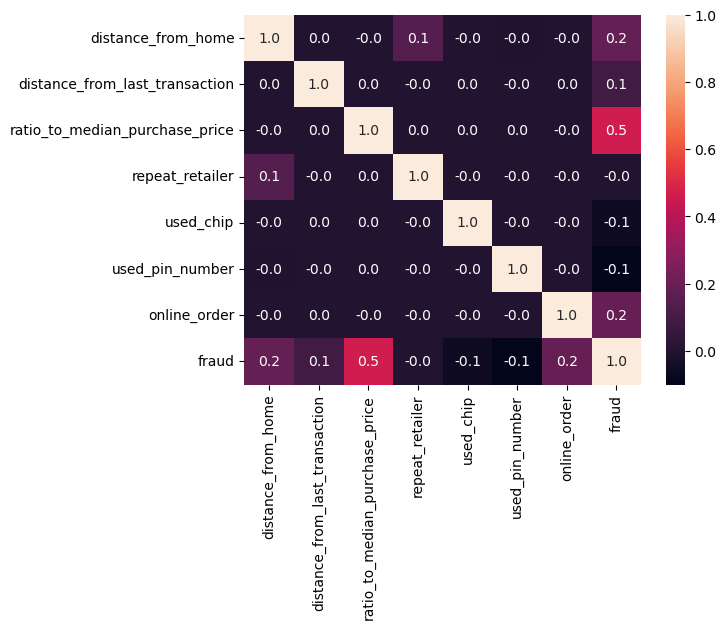

In [17]:
# Visualize correlations
def show_heatmap(df):
    sn.heatmap(data = df.corr(), annot = True, fmt='.1f')
    plt.show()

show_heatmap(fraud_df)

Step 3. Data Cleaning

There will be no outliers removal, since outlier values in the features distance_from_home, distance_from_last_transaction andratio_to_median_purchase_price could be perfect indicators for fraud detection. These outliers make the data hard to normalize or standardize, thus a robust scaling would be a better option.

Removal of duplicated data won't be executed either, for dulpicated instances in this case may also contain useful information for the task

In [18]:
# Find missing values
for feature in fraud_df.columns:
    print(f'Total missing values for {feature}: {fraud_df[feature].isna().sum()}')

Total missing values for distance_from_home: 0
Total missing values for distance_from_last_transaction: 0
Total missing values for ratio_to_median_purchase_price: 0
Total missing values for repeat_retailer: 0
Total missing values for used_chip: 0
Total missing values for used_pin_number: 0
Total missing values for online_order: 0
Total missing values for fraud: 0


Step 4. Data Transformation

Since we are dealing with an imbalanced datset, either oversampling or undersampling is required to avoid bias in the final classifier. Oversampling increases the risk of overfitting, while undersampling increases the risk of information loss. With almost 1M instances, it is less probable to lose information by undersampling than it is to overfit bu oversampling. There is also the factor that a personal computer (like mine) will take too long for training multiple algorithms with an oversampled dataset of 2M instances.
For these two reasons, I will perform undersampling on the majority class.

In [19]:
y = fraud_df.fraud
X = fraud_df.drop(columns=['fraud'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def undersample_data(X, y):
    rus = RandomUnderSampler(random_state=42)

    '''
    Although ClusterCentroids may preserve the majority class distribution more effectively than random undersampling, 
    its execution time on a dataset of this size was excessive for my available hardware resources.
    '''
    X_resampled, y_resampled = rus.fit_resample(X, y)
    return X_resampled, y_resampled

under_X_train, under_y_train = undersample_data(X_train, y_train)

print("Test set class distribution:")
print(y_test.value_counts())

print("\nUndersampled training set class distribution:")
print(under_y_train.value_counts())

Test set class distribution:
fraud
0.0    182519
1.0     17481
Name: count, dtype: int64

Undersampled training set class distribution:
fraud
0.0    69922
1.0    69922
Name: count, dtype: int64


In [20]:
def transform_data(X_train, X_test):
    'Since there are many outliers in the data, I chose to use a robust scaler'
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = transform_data(under_X_train, X_test)
X_train_scaled

array([[-2.58203801e-01, -2.88699127e-01,  2.24361077e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.52406366e-01,  7.59773626e+00,  6.18275069e-03, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.66328864e-01,  4.02917541e+00, -4.17529137e-01, ...,
         0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
       ...,
       [ 4.80443792e+00,  4.97465007e-01, -2.84394066e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.85017714e-01, -2.45322028e-01,  5.95143427e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.14671572e+00, -2.71649439e-01,  7.27571206e-01, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(139844, 7))

Step 5. Train and Compare Models

In [21]:
def test_f1_recall(best_model, X80, X20, y80, y20, threshold=None):
    # Test accuracy and recall for train and test (to look for best model and assure no overfitting is happening)

    if threshold is None:
        y20_predicted = best_model.predict(X20)
        y80_predicted = best_model.predict(X80)
    else:
        y20_proba = best_model.predict_proba(X20)[:, 1]
        y80_proba = best_model.predict_proba(X80)[:, 1]

        y20_predicted = (y20_proba >= threshold).astype(int)
        y80_predicted = (y80_proba >= threshold).astype(int)

    train_f1 = round(f1_score(y80, y80_predicted),3)
    test_f1 = round(f1_score(y20, y20_predicted),3)
    train_recall = round(recall_score(y80, y80_predicted),3)
    test_recall = round(recall_score(y20, y20_predicted),3)

    return (f'train f1 = {train_f1}, test f1 = {test_f1}, train recall = {train_recall}, test recall = {test_recall}')

def train_rf(X80, X20, y80, y20):
    clf = RandomForestClassifier(random_state=42, n_jobs=-1)

    # Find best parameters for the model
    grid_values = {'n_estimators': [25, 50], 'max_features': [3, 5], 'max_depth' : [3, 5, 8, None]}
    grid_clf = GridSearchCV(clf, 
                            param_grid = grid_values, 
                            scoring='f1',
                            cv=3,
                            n_jobs=-1
    )
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return test_f1_recall(best_model, X80, X20, y80, y20, threshold=0.40)

def train_gb(X80, X20, y80, y20):
    #clf = GradientBoostingClassifier()
    clf = HistGradientBoostingClassifier(random_state=42, max_iter=500)

    # Find best parameters for the model
    grid_values = {'max_depth' : [3, 4], 'learning_rate': [0.01, 0.05, 0.2]}
    grid_clf = GridSearchCV(clf, 
                            param_grid = grid_values, 
                            scoring='f1', 
                            cv=3,
                            n_jobs=-1)
    grid_clf.fit(X80, y80)
    best_model = grid_clf.best_estimator_

    return test_f1_recall(best_model, X80, X20, y80, y20, threshold=0.40)

def train_models(X80, X20, y80, y20):
    results = dict()
    results['Random Forest'] = train_rf(X80, X20, y80, y20)
    results['Gradient Boosting'] = train_gb(X80, X20, y80, y20)
    return results


# Train different models and return their f1 and recall to compare their performance
model_scores = train_models(X_train_scaled, X_test_scaled, under_y_train, y_test)
model_scores

{'Random Forest': 'train f1 = 1.0, test f1 = 0.999, train recall = 1.0, test recall = 1.0',
 'Gradient Boosting': 'train f1 = 0.999, test f1 = 0.988, train recall = 1.0, test recall = 0.999'}

F1-score was selected as the primary evaluation metric because it balances both precision and recall, making it more appropriate for imbalanced classification problems such as fraud detection. Recall was also included as an additional metric due to the importance of correctly identifying fraudulent transactions.

The unusually high F1 and recall scores may be influenced by the nature of the dataset itself. The dataset is likely synthetic or highly engineered, potentially containing:
- artificially separable patterns
- engineered fraud signatures
- simplified feature distributions